# M7 · The Production Ranker, For Real — Implementing the Architecture Flowchart

**Companion to lesson M7. For a new student who wants the *real* thing.**

The other two notebooks used simple models (logistic regression, a plain network) to
teach the *pipeline*. This one **implements the actual architectures** from the M7
"common default path" flowchart, in real **PyTorch** — the same building blocks used in
production ad rankers:

| Flowchart stage | We implement |
|---|---|
| 1 · Feature interactions | **DCN-V2 cross network** (explicit feature crosses) |
| 2 · User history | **DIN** — attention over the user's past behavior |
| 3 · Multiple objectives | **MMoE** — experts + gates → three heads (CTR / VTR / LTR) |
| 4 · Label bias | **position-as-feature** debiasing |
| 5 · Re-ranking | **MMR** diversity re-ranking of the final slate |
| 6 · Evaluate | per-head **AUC** + **calibration** |

Every piece has: a plain-English explanation, **print logging** so you see shapes and
numbers, and a **picture**. Runs top-to-bottom in Colab (PyTorch is already installed
there). Read the note above each cell, then run it (**Shift+Enter**).

## Step 0 · Imports and a quick check

We use **PyTorch** (`torch`) to build the network. In Google Colab it's already
installed. This cell just imports everything and prints the version so we know we're
ready.

In [1]:
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"
HEADS = ["CTR", "VTR", "LTR"]; HEAD_COLORS = [BLUE, GREEN, PURPLE]

torch.manual_seed(0)
rng = np.random.default_rng(0)
print("PyTorch version:", torch.__version__, "| ready.")

PyTorch version: 2.8.0 | ready.


## Step 1 · Build the data — user **history** (this is what DIN needs)

DIN's whole idea is attention over a user's **past behavior**, so our data needs a
*history sequence* per impression. We create:
- `G = 6` item **genres** (think: sports, cooking, tech, ...).
- Each impression carries a **history** of the last `H = 12` genres this user interacted
  with. We bias each user toward a favourite genre, so their history is informative.
- A **candidate** item genre (the ad we're about to score).

The key hidden signal is **affinity** = how much of the user's history matches the
candidate's genre. A good history model (DIN) should recover this from attention.

In [2]:
N, G, H = 9000, 6, 12
genres = ["sports", "cooking", "tech", "travel", "finance", "music"]

pref = rng.integers(0, G, N)                         # each user's favourite genre
hist = np.stack([rng.choice(G, size=H, p=[(0.6 if g == pref[i] else 0.4/(G-1)) for g in range(G)])
                 for i in range(N)])                 # (N, H) history of genre ids
cand_genre = rng.integers(0, G, N)                   # the candidate ad's genre
affinity = np.array([(hist[i] == cand_genre[i]).mean() for i in range(N)])   # hidden signal

print("history shape (impressions x history length):", hist.shape)
print("example user 0 favourite genre:", genres[pref[0]])
print("user 0 history genres:", [genres[g] for g in hist[0]])
print("user 0 candidate genre:", genres[cand_genre[0]], "-> affinity:", round(affinity[0], 2))

history shape (impressions x history length): (9000, 12)
example user 0 favourite genre: music
user 0 history genres: ['cooking', 'music', 'music', 'music', 'music', 'music', 'music', 'music', 'music', 'music', 'sports', 'tech']
user 0 candidate genre: music -> affinity: 0.75


## Step 2 · Candidate features, position, and the three labels

Alongside history we have normal features: `relevance`, `ad_quality`, `price`,
`is_video`, and `position` (slot 1–10). Then we invent the true rules for three outcomes
— **click (CTR)**, **view (VTR)**, **lead (LTR)** — each leaning on **affinity** so the
history model has something real to find. `position` lowers clicks (a **bias** we'll deal
with in Step 8).

base rates -> CTR 0.363 VTR 0.486 LTR 0.515


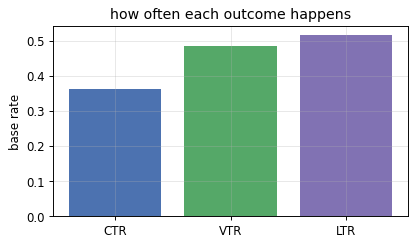

In [3]:
def sig(z): return 1 / (1 + np.exp(-z))
relevance = rng.uniform(0,1,N); ad_quality = rng.uniform(0,1,N); price = rng.uniform(0,1,N)
is_video  = rng.integers(0,2,N); position = rng.integers(1,11,N)

click = (rng.random(N) < sig(-1.8 + 2.2*relevance + 1.0*ad_quality - 0.18*position + 3.0*affinity)).astype(np.float32)
view  = (rng.random(N) < sig(-1.4 + 0.8*ad_quality + 2.2*is_video - 0.10*position + 2.4*affinity)).astype(np.float32)
lead  = (rng.random(N) < sig(-2.2 + 2.2*relevance + 1.6*price + 2.2*affinity)).astype(np.float32)

print("base rates -> CTR", round(click.mean(),3), "VTR", round(view.mean(),3), "LTR", round(lead.mean(),3))
plt.figure(figsize=(5,3)); plt.bar(HEADS, [click.mean(), view.mean(), lead.mean()], color=HEAD_COLORS)
plt.ylabel("base rate"); plt.title("how often each outcome happens"); plt.show()

## Step 3 · Pack into tensors and split train/test

We standardize the dense features (mean 0 / spread 1, using **train** stats only), then
turn everything into PyTorch **tensors** — the arrays the network consumes. We log the
shapes so you can see what goes in.

In [4]:
dense = np.c_[relevance, ad_quality, price, is_video, position].astype(np.float32)
n_tr = 6750
mu, sd = dense[:n_tr].mean(0), dense[:n_tr].std(0)
dense = (dense - mu) / sd
Y = np.c_[click, view, lead].astype(np.float32)

def T(a): return torch.tensor(a)
tr, te = slice(0, n_tr), slice(n_tr, N)
Dtr, Ctr, Htr, Ytr = T(dense[tr]), T(cand_genre[tr]), T(hist[tr]), T(Y[tr])
Dte, Cte, Hte, Yte = T(dense[te]), T(cand_genre[te]), T(hist[te]), T(Y[te])
print("train:", Dtr.shape[0], "test:", Dte.shape[0])
print("per impression -> dense features:", Dtr.shape[1],
      "| candidate genre: 1 id | history:", Htr.shape[1], "genre ids | labels:", Ytr.shape[1])

train: 6750 test: 2250
per impression -> dense features: 5 | candidate genre: 1 id | history: 12 genre ids | labels: 3


## Step 4 · Embeddings — turn genre IDs into vectors

A network can't do math on the word "sports". An **embedding table** is a lookup that
gives every genre a short learnable vector (here length 8). Genres that behave similarly
end up with similar vectors. Both the candidate genre and every history genre use the
**same** table, so they live in the same space — which is what lets DIN compare them.

In [5]:
EMB_DIM = 8
genre_emb = nn.Embedding(G, EMB_DIM)
demo = genre_emb(torch.tensor([0, 1]))
print("genre embedding table shape:", genre_emb.weight.shape, "(6 genres x 8 numbers each)")
print("embedding for 'sports' (genre 0):", np.round(demo[0].detach().numpy(), 2))

genre embedding table shape: torch.Size([6, 8]) (6 genres x 8 numbers each)
embedding for 'sports' (genre 0): [-1.13 -1.15 -0.25 -0.43  0.85  0.69 -0.32 -2.12]


## Step 5 · DIN — attention over history (Stage 2 of the flowchart)

**The idea in one sentence:** don't average all of a user's history equally — pay more
**attention** to the past items that are *relevant to the ad we're scoring right now*.

How it works, step by step:
1. Embed the candidate genre (the "query") and every history genre (the "keys").
2. For each history item, build interaction features `[query, key, query−key, query×key]`
   and pass them through a tiny network to get one **attention score**.
3. **Softmax** the scores → weights that sum to 1 (how much to listen to each past item).
4. The history vector = the weighted sum of history embeddings.

Because the weights depend on the candidate, the **same history produces a different
summary for different ads** — that's "candidate-aware," DIN's superpower.

In [6]:
class DIN(nn.Module):
    def __init__(self, emb, dim):
        super().__init__()
        self.emb = emb
        self.att = nn.Sequential(nn.Linear(4*dim, dim), nn.ReLU(), nn.Linear(dim, 1))
    def forward(self, cand, hist):
        c = self.emb(cand)                      # (B, d)  the candidate = the "query"
        h = self.emb(hist)                      # (B, H, d) the history  = the "keys/values"
        q = c.unsqueeze(1).expand_as(h)         # repeat the query for every history slot
        feats = torch.cat([q, h, q - h, q * h], dim=-1)   # DIN interaction features
        scores = self.att(feats).squeeze(-1)    # (B, H) one score per history item
        weights = torch.softmax(scores, dim=-1) # (B, H) attention weights, sum to 1
        hist_vec = (weights.unsqueeze(-1) * h).sum(dim=1)  # (B, d) weighted summary
        return hist_vec, weights, c

din_test = DIN(genre_emb, EMB_DIM)
hv, w, _ = din_test(Cte[:2], Hte[:2])
print("history vector shape:", hv.shape, "| attention weights shape:", w.shape)
print("attention weights for impression 0 (sum =", round(float(w[0].sum()),2), "):")
print(np.round(w[0].detach().numpy(), 3))

history vector shape: torch.Size([2, 8]) | attention weights shape: torch.Size([2, 12])
attention weights for impression 0 (sum = 1.0 ):
[0.097 0.074 0.085 0.074 0.085 0.085 0.074 0.086 0.085 0.085 0.085 0.085]


## Step 6 · DCN-V2 cross network (Stage 1 of the flowchart)

Plain networks mix features only *implicitly*. A **cross network** builds **explicit**
feature crosses — products like `relevance × affinity`, then crosses of crosses — cheaply
and automatically. Each cross layer computes `x0 * (W·x + b) + x`: it multiplies the
**original** input `x0` by a learned transform of the current features, then adds the
current features back (a "residual"). Stacking `k` layers gives crosses up to degree
`k+1`.

In [7]:
class CrossNet(nn.Module):
    def __init__(self, dim, n_layers=2):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(dim, dim) for _ in range(n_layers)])
    def forward(self, x0):
        x = x0
        for layer in self.layers:
            x = x0 * layer(x) + x        # explicit cross + residual
        return x

cn = CrossNet(4, 2)
print("a 2-layer cross network on a 4-dim input keeps the same shape:",
      tuple(cn(torch.randn(3, 4)).shape), "(it enriches, doesn't shrink)")

a 2-layer cross network on a 4-dim input keeps the same shape: (3, 4) (it enriches, doesn't shrink)


## Step 7 · MMoE — multi-task with experts + gates (Stage 3 of the flowchart)

We predict **three** things (click, view, lead). Forcing them through one shared network
makes them fight ("negative transfer"). **MMoE** fixes this:
- several small **expert** networks each learn a different view of the input,
- each **task** has its own **gate** — a softmax that decides *how much of each expert*
  that task uses.

So the click task can lean on one expert while the lead task leans on another, sharing
where it helps and specializing where it doesn't. Each task then has a small **head**
that outputs its logit.

In [8]:
class MMoE(nn.Module):
    def __init__(self, dim, n_experts=4, n_tasks=3, hid=32):
        super().__init__()
        self.experts = nn.ModuleList([nn.Sequential(nn.Linear(dim, hid), nn.ReLU()) for _ in range(n_experts)])
        self.gates   = nn.ModuleList([nn.Linear(dim, n_experts) for _ in range(n_tasks)])
        self.heads   = nn.ModuleList([nn.Linear(hid, 1) for _ in range(n_tasks)])
    def forward(self, x):
        E = torch.stack([e(x) for e in self.experts], dim=1)   # (B, n_experts, hid)
        logits, gates = [], []
        for gate, head in zip(self.gates, self.heads):
            g = torch.softmax(gate(x), dim=-1)                 # (B, n_experts) per-task gate
            gates.append(g)
            mixed = (g.unsqueeze(-1) * E).sum(dim=1)           # blend experts for this task
            logits.append(head(mixed).squeeze(-1))
        return torch.stack(logits, dim=1), torch.stack(gates, dim=1)

print("MMoE: 4 experts, 3 per-task gates, 3 heads -> one logit per task.")

MMoE: 4 experts, 3 per-task gates, 3 heads -> one logit per task.


## Step 8 · Assemble the full model (and handle position bias)

Now we stack the pieces exactly like the flowchart:
`DIN(history) → concat with dense + candidate → DCN cross (+ a deep branch) → MMoE → 3 heads`.

**Position bias (Stage 4):** items shown in the top slot get clicked partly *because*
they're on top, not because they're better. We include `position` as a **feature** during
training so the model can *explain away* that effect; at **serving** time we feed a neutral
position so ranking reflects true quality, not slot luck. (We'll demonstrate this in
Step 12.)

In [9]:
class Ranker(nn.Module):
    def __init__(self, G, emb_dim=EMB_DIM, n_dense=5):
        super().__init__()
        self.emb = nn.Embedding(G, emb_dim)
        self.din = DIN(self.emb, emb_dim)
        dim = n_dense + emb_dim + emb_dim          # dense + candidate emb + history vec
        self.cross = CrossNet(dim, 2)
        self.deep  = nn.Sequential(nn.Linear(dim, 32), nn.ReLU())
        self.mmoe  = MMoE(dim + 32)
    def forward(self, dense, cand, hist):
        hist_vec, attn, cand_emb = self.din(cand, hist)
        x = torch.cat([dense, cand_emb, hist_vec], dim=-1)
        z = torch.cat([self.cross(x), self.deep(x)], dim=-1)   # DCN branch + deep branch
        logits, gates = self.mmoe(z)
        return logits, attn, gates

model = Ranker(G)
n_params = sum(p.numel() for p in model.parameters())
print("full model built. total learnable numbers (parameters):", n_params)
print("pipeline: DIN -> [dense|cand|history] -> DCN cross + deep -> MMoE -> CTR/VTR/LTR")

full model built. total learnable numbers (parameters): 9608
pipeline: DIN -> [dense|cand|history] -> DCN cross + deep -> MMoE -> CTR/VTR/LTR


## Step 9 · Train — and log the loss going down

Training = show the model the data many times (**epochs**); each epoch it predicts,
measures error (**BCE loss**, summed over the three heads), and nudges its weights to do
better (**Adam** optimizer). We **print the loss every few epochs** and store it for a
curve. Watch the total loss fall.

In [10]:
opt = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

hist_total, hist_tasks = [], []
print("epoch |  total | CTR   VTR   LTR   (per-head loss)")
for epoch in range(70):
    model.train(); opt.zero_grad()
    logits, _, _ = model(Dtr, Ctr, Htr)
    per_task = [loss_fn(logits[:, k], Ytr[:, k]) for k in range(3)]
    loss = sum(per_task)
    loss.backward(); opt.step()
    hist_total.append(loss.item()); hist_tasks.append([l.item() for l in per_task])
    if epoch % 10 == 0:
        pt = [round(l.item(), 3) for l in per_task]
        print(f"{epoch:5d} | {loss.item():.3f} | {pt[0]:.3f} {pt[1]:.3f} {pt[2]:.3f}")
print("done. final total loss:", round(hist_total[-1], 3))

epoch |  total | CTR   VTR   LTR   (per-head loss)
    0 | 2.087 | 0.692 0.700 0.694
   10 | 1.782 | 0.585 0.572 0.625
   20 | 1.709 | 0.560 0.538 0.611
   30 | 1.672 | 0.547 0.526 0.599
   40 | 1.642 | 0.539 0.516 0.588
   50 | 1.608 | 0.529 0.505 0.574
   60 | 1.565 | 0.516 0.493 0.556
done. final total loss: 1.524


## Step 10 · The learning curves

Total loss and each head's loss over training. All should fall and flatten — the shared
model is learning all three tasks at once.

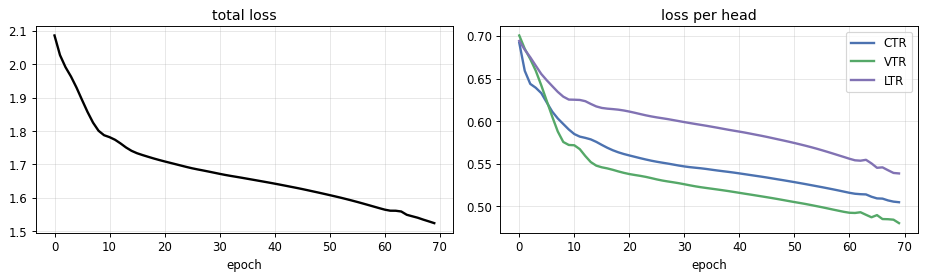

In [11]:
hist_tasks = np.array(hist_tasks)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(hist_total, color="black", lw=2); ax[0].set_title("total loss"); ax[0].set_xlabel("epoch")
for k, (name, c) in enumerate(zip(HEADS, HEAD_COLORS)):
    ax[1].plot(hist_tasks[:, k], color=c, lw=2, label=name)
ax[1].set_title("loss per head"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.show()

## Step 11 · Evaluate each head — AUC

Predict on the held-out test set and score each head with **AUC** (chance a positive is
ranked above a negative; 0.5 = coin flip, 1.0 = perfect).

CTR AUC: 0.729
VTR AUC: 0.753
LTR AUC: 0.675


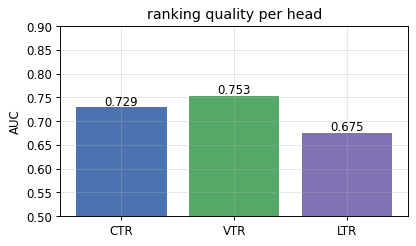

In [12]:
model.eval()
with torch.no_grad():
    logits_te, attn_te, gates_te = model(Dte, Cte, Hte)
proba = torch.sigmoid(logits_te).numpy()
aucs = [roc_auc_score(Y[te][:, k], proba[:, k]) for k in range(3)]
for name, a in zip(HEADS, aucs): print(f"{name} AUC: {a:.3f}")
plt.figure(figsize=(5,3)); plt.bar(HEADS, aucs, color=HEAD_COLORS); plt.ylim(0.5, 0.9)
for i,a in enumerate(aucs): plt.text(i, a+0.005, f"{a:.3f}", ha="center")
plt.ylabel("AUC"); plt.title("ranking quality per head"); plt.show()

## Step 12 · Position debias in action

Here's the payoff of including `position` as a feature. We score the same impressions
twice: once with their **real** position, once with everyone forced to the **top slot**
(neutral). If the model learned the position effect, the neutralized scores strip out the
"clicked just because it was high" boost — that's the version you rank with at serving.

avg pCTR with real position: 0.36
avg pCTR with neutral (top) position: 0.508


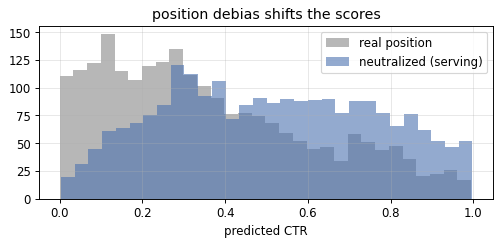

In [13]:
neutral = Dte.clone()
pos_col = 4                                  # position is the 5th dense feature
neutral[:, pos_col] = (1 - mu[pos_col]) / sd[pos_col]   # force everyone to slot 1 (standardized)
with torch.no_grad():
    p_real = torch.sigmoid(model(Dte, Cte, Hte)[0][:, 0]).numpy()
    p_neut = torch.sigmoid(model(neutral, Cte, Hte)[0][:, 0]).numpy()
print("avg pCTR with real position:", round(p_real.mean(), 3))
print("avg pCTR with neutral (top) position:", round(p_neut.mean(), 3))
plt.figure(figsize=(6,3))
plt.hist(p_real, bins=30, alpha=.6, color=GRAY, label="real position")
plt.hist(p_neut, bins=30, alpha=.6, color=BLUE, label="neutralized (serving)")
plt.xlabel("predicted CTR"); plt.legend(); plt.title("position debias shifts the scores"); plt.show()

## Step 13 · Look inside DIN — is the attention really candidate-aware?

The proof DIN works: for each test impression, we measure how much attention landed on
history items whose genre **matches** the candidate vs those that **don't**. If DIN is
doing its job, far more attention goes to **matching** history — it's focusing on the
relevant past.

avg attention on MATCHING-genre history: 0.124
avg attention on other history         : 0.077


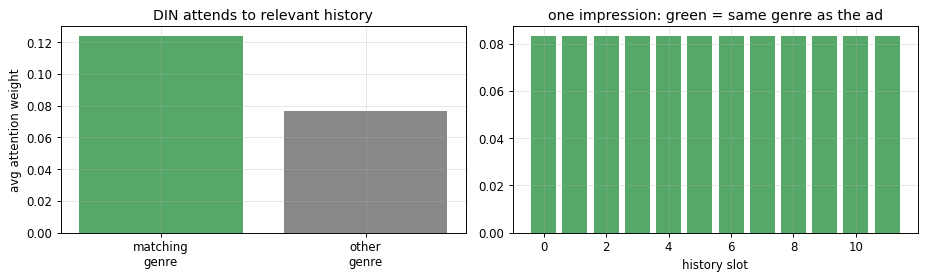

In [14]:
attn = attn_te.numpy()                       # (test, H)
match = (Hte.numpy() == Cte.numpy()[:, None])# (test, H) True where history genre == candidate
# average attention on matching vs non-matching history slots
att_match = np.array([attn[i][match[i]].mean() if match[i].any() else np.nan for i in range(len(attn))])
att_other = np.array([attn[i][~match[i]].mean() if (~match[i]).any() else np.nan for i in range(len(attn))])
print("avg attention on MATCHING-genre history:", round(np.nanmean(att_match), 3))
print("avg attention on other history         :", round(np.nanmean(att_other), 3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(["matching\ngenre", "other\ngenre"], [np.nanmean(att_match), np.nanmean(att_other)], color=[GREEN, GRAY])
ax[0].set_ylabel("avg attention weight"); ax[0].set_title("DIN attends to relevant history")
# one concrete example: attention over user 0's 12 history slots, colored by match
i = int(np.argmax(match.sum(1)))             # pick a user with several matching items
colors = [GREEN if m else GRAY for m in match[i]]
ax[1].bar(range(H), attn[i], color=colors)
ax[1].set_title(f"one impression: green = same genre as the ad"); ax[1].set_xlabel("history slot")
plt.show()

## Step 14 · Look inside MMoE — do the tasks use different experts?

We average each task's **gate** over the test set: rows = tasks (CTR/VTR/LTR), columns =
experts, values = how much each task relies on each expert. Different rows = the tasks
specialized to different experts, which is exactly why MMoE beats a single shared network
when tasks conflict.

gate rows differ across tasks -> the heads specialized:
  CTR: [0.17 0.31 0.43 0.09]
  VTR: [0.61 0.18 0.03 0.19]
  LTR: [0.19 0.21 0.12 0.48]


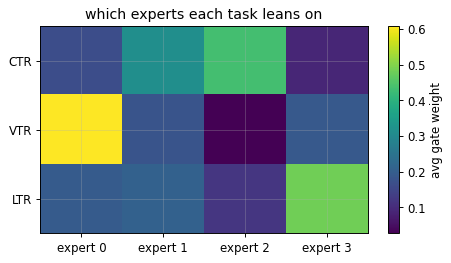

In [15]:
avg_gates = gates_te.mean(0).numpy()         # (3 tasks, n_experts)
plt.figure(figsize=(5.5, 3.2))
im = plt.imshow(avg_gates, cmap="viridis", aspect="auto")
plt.colorbar(im, label="avg gate weight")
plt.yticks(range(3), HEADS); plt.xticks(range(avg_gates.shape[1]), [f"expert {j}" for j in range(avg_gates.shape[1])])
plt.title("which experts each task leans on"); plt.show()
print("gate rows differ across tasks -> the heads specialized:")
for name, row in zip(HEADS, avg_gates): print(f"  {name}: {np.round(row,2)}")

## Step 15 · Calibration per head

Each head should be honest: when it says 0.3, about 30% should happen. Reliability curves
on the diagonal = trustworthy — needed because the serving score multiplies these.

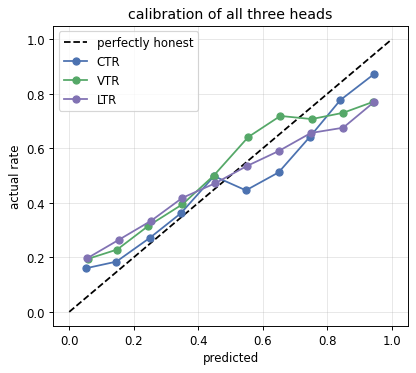

In [16]:
plt.figure(figsize=(5, 4.5)); plt.plot([0,1],[0,1], "k--", label="perfectly honest")
for k, (name, c) in enumerate(zip(HEADS, HEAD_COLORS)):
    frac, mean = calibration_curve(Y[te][:, k], proba[:, k], n_bins=10)
    plt.plot(mean, frac, "o-", color=c, label=name)
plt.xlabel("predicted"); plt.ylabel("actual rate"); plt.legend(); plt.title("calibration of all three heads"); plt.show()

## Step 16 · Does the history model earn its keep? (ablation)

We scramble each user's history (feed random genres) and re-score. If DIN's history was
carrying real signal, every head's AUC should **drop**. This is how you justify the extra
complexity of a history model.

head   real history  scrambled   drop
CTR           0.729      0.677  0.052
VTR           0.753      0.741  0.012
LTR           0.675      0.662  0.013


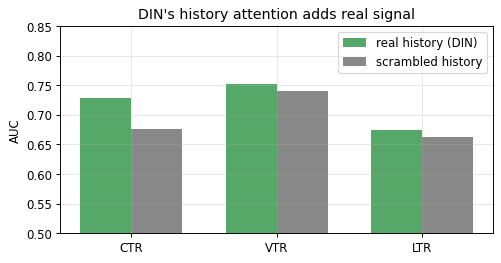

In [17]:
Hrand = torch.randint(0, G, Hte.shape)
with torch.no_grad():
    proba_rand = torch.sigmoid(model(Dte, Cte, Hrand)[0]).numpy()
aucs_rand = [roc_auc_score(Y[te][:, k], proba_rand[:, k]) for k in range(3)]
print(f"{'head':<5}{'real history':>14}{'scrambled':>11}{'drop':>7}")
for name, a, ar in zip(HEADS, aucs, aucs_rand):
    print(f"{name:<5}{a:>14.3f}{ar:>11.3f}{a-ar:>7.3f}")
x = np.arange(3); wd = 0.35
plt.figure(figsize=(6,3.2))
plt.bar(x-wd/2, aucs, wd, color=GREEN, label="real history (DIN)")
plt.bar(x+wd/2, aucs_rand, wd, color=GRAY, label="scrambled history")
plt.xticks(x, HEADS); plt.ylim(0.5, 0.85); plt.ylabel("AUC"); plt.legend()
plt.title("DIN's history attention adds real signal"); plt.show()

## Step 17 · Re-ranking with MMR (Stage 5 of the flowchart)

Ranking each item alone can fill the whole page with **near-duplicates** (all the same
genre). **Re-ranking** looks at the slate *as a set*. We use **MMR** (Maximal Marginal
Relevance): build the slate greedily, each step picking the item that maximizes

`score = λ · (model score) − (1 − λ) · (similarity to what's already picked)`

so a slightly lower-scoring item from a *fresh* genre can beat yet another duplicate. We
build one user's candidate slate, rank by model score, then MMR-rerank and compare.

In [18]:
# make a candidate pool for ONE user: many items across genres, same user history
np_rng = np.random.default_rng(3)
M = 40
u_hist = Hte[:1].repeat(M, 1)                         # this user's history, repeated
c_gen = torch.tensor(np_rng.integers(0, G, M))        # candidate genres across the pool
d_pool = torch.tensor(((np.c_[np_rng.uniform(0,1,M), np_rng.uniform(0,1,M), np_rng.uniform(0,1,M),
                              np_rng.integers(0,2,M), np_rng.integers(1,11,M)].astype(np.float32) - mu)/sd))
with torch.no_grad():
    lg, _, _ = model(d_pool, c_gen, u_hist)
    # multi-objective serving score
    scores = (0.5*torch.sigmoid(lg[:,0]) + 0.2*torch.sigmoid(lg[:,1]) + 0.3*torch.sigmoid(lg[:,2])).numpy()

def mmr(scores, genres_, k=10, lam=0.7):
    picked, cand = [], list(range(len(scores)))
    while len(picked) < k and cand:
        best, best_val = None, -1e9
        for i in cand:
            sim = 1.0 if any(genres_[i] == genres_[j] for j in picked) else 0.0  # same-genre = redundant
            val = lam*scores[i] - (1-lam)*sim
            if val > best_val: best, best_val = i, val
        picked.append(best); cand.remove(best)
    return picked

top_by_score = list(np.argsort(-scores)[:10])
top_by_mmr   = mmr(scores, c_gen.numpy(), k=10, lam=0.7)
g_score = [genres[c_gen[i]] for i in top_by_score]
g_mmr   = [genres[c_gen[i]] for i in top_by_mmr]
print("top-10 by SCORE only  ->", g_score)
print("  distinct genres:", len(set(g_score)))
print("top-10 after MMR      ->", g_mmr)
print("  distinct genres:", len(set(g_mmr)))

top-10 by SCORE only  -> ['sports', 'cooking', 'sports', 'cooking', 'travel', 'tech', 'cooking', 'sports', 'travel', 'tech']
  distinct genres: 4
top-10 after MMR      -> ['sports', 'cooking', 'travel', 'tech', 'music', 'finance', 'sports', 'cooking', 'cooking', 'sports']
  distinct genres: 6


## Step 18 · Re-ranking, visualized — relevance vs diversity

Left: how many distinct genres make the top-10 (higher = more diverse). Right: the total
model score of the slate (MMR gives up a little to gain variety). This is the
relevance-vs-diversity tradeoff the `λ` knob controls.

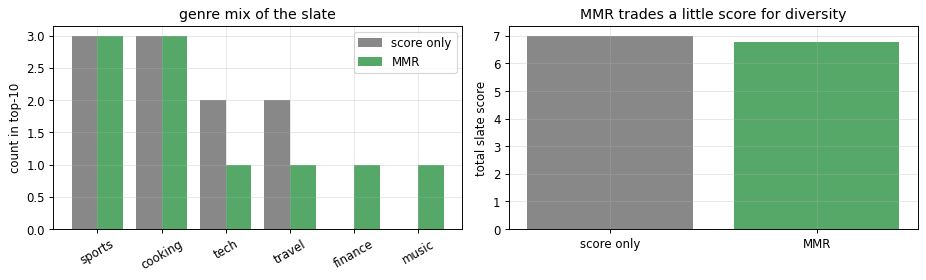

In [19]:
import collections
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for j, (lab, sel, col) in enumerate([("score only", top_by_score, GRAY), ("MMR", top_by_mmr, GREEN)]):
    cnt = collections.Counter(genres[c_gen[i]] for i in sel)
    ax[0].bar(np.arange(G)+ (j*0.4-0.2), [cnt.get(genres[g],0) for g in range(G)], 0.4, color=col, label=lab)
ax[0].set_xticks(range(G)); ax[0].set_xticklabels(genres, rotation=30); ax[0].set_ylabel("count in top-10")
ax[0].set_title("genre mix of the slate"); ax[0].legend()
ax[1].bar(["score only", "MMR"], [scores[top_by_score].sum(), scores[top_by_mmr].sum()], color=[GRAY, GREEN])
ax[1].set_ylabel("total slate score"); ax[1].set_title("MMR trades a little score for diversity")
plt.show()

---
## Recap — you implemented the whole flowchart

Every stage of the M7 "common default path", in real PyTorch:
1. **DCN-V2 cross network** — explicit feature crosses (Step 6).
2. **DIN** — candidate-aware attention over user history; you *saw* it focus on the
   matching genre (Step 5, 13).
3. **MMoE** — experts + per-task gates → CTR/VTR/LTR heads; you *saw* the tasks pick
   different experts (Step 7, 14).
4. **Position-as-feature debias** — neutralize slot luck at serving (Step 8, 12).
5. **MMR re-ranking** — diversify the final slate (Step 17, 18).
6. **Evaluate** — per-head AUC, calibration, and a history ablation (Steps 11, 15, 16).

**Scaling up in the real world:** swap DIN for **DIEN/BST/SIM** for longer history, MMoE
for **PLE** under heavier task conflict, and add **ESMM** if conversions only follow
clicks — the exact "upgrade when…" arrows on the flowchart. You now have the real mental
model *and* the working code of a production ranker. 🚀